In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set()

## Medidas de distancia
**Aprendizaje de Máquina - CEIA - FIUBA**

In [2]:
# Punto de referencia
punto = np.array([0.0, 0.0])

# Genero puntos para comparar distancias

# Puntos aleatorios
# n_random = 100
# x_points = np.random.uniform(-2, 2, n_random)
# y_points = np.random.uniform(-2, 2, n_random)

# Puntos en radios concéntricos
radii = [0.5, 1.0, 1.5, 2.0]
k = 20  # factor de densidad

x_points = []
y_points = []

for r in radii:
    n_points = max(6, int(k * r))  # mínimo 6 puntos por círculo
    theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    x_points.extend(punto[0] + r * np.cos(theta))
    y_points.extend(punto[1] + r * np.sin(theta))

x_points = np.array(x_points)
y_points = np.array(y_points)

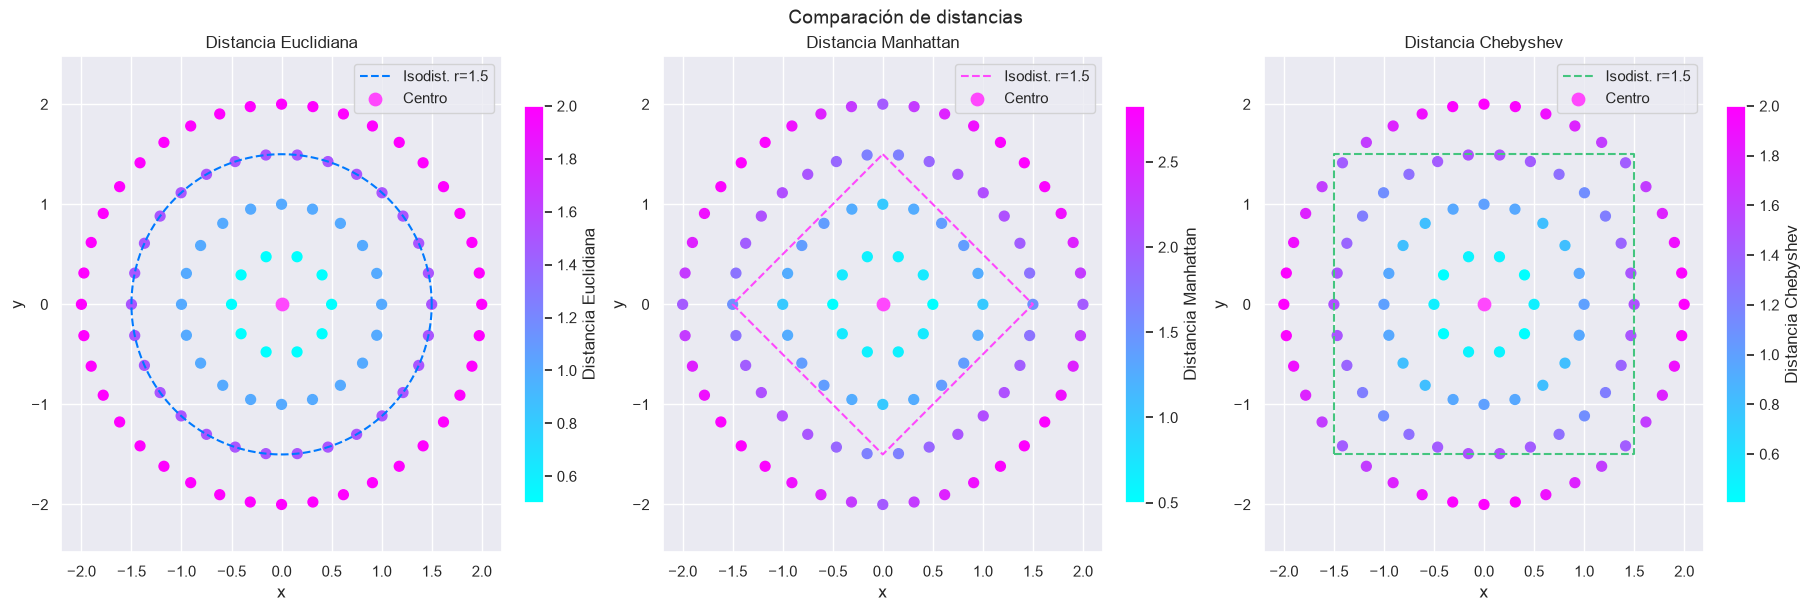

In [3]:
# Isodistancia
r = 1.5

# Isodistancia Euclidiana
theta = np.linspace(0, 2*np.pi, 400)
euclid_x = punto[0] + r * np.cos(theta)
euclid_y = punto[1] + r * np.sin(theta)

# Isodistancia Manhattan
manhattan_x = [punto[0], punto[0]+r, punto[0], punto[0]-r, punto[0]]
manhattan_y = [punto[1]+r, punto[1], punto[1]-r, punto[1], punto[1]+r]

# Isodistancia Chebyshev
chebyshev_x = [punto[0]-r, punto[0]+r, punto[0]+r, punto[0]-r, punto[0]-r]
chebyshev_y = [punto[1]-r, punto[1]-r, punto[1]+r, punto[1]+r, punto[1]-r]

# Calculo distancias
dist_manhattan = np.abs(x_points - punto[0]) + np.abs(y_points - punto[1])
dist_euclid = np.sqrt((x_points - punto[0])**2 + (y_points - punto[1])**2)
dist_chebyshev = np.maximum(np.abs(x_points - punto[0]), np.abs(y_points - punto[1]))

# Subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for ax, dist, iso_x, iso_y, color_iso, titulo, label_cb in [
    (axes[0], dist_euclid, euclid_x, euclid_y, '#007aff', 
        'Distancia Euclidiana', 'Distancia Euclidiana'),
    (axes[1], dist_manhattan, manhattan_x, manhattan_y, '#ff48fd',
        'Distancia Manhattan', 'Distancia Manhattan'),
    (axes[2], dist_chebyshev, chebyshev_x, chebyshev_y, '#44c57f',
        'Distancia Chebyshev', 'Distancia Chebyshev'),
]:
    sc = ax.scatter(x_points, y_points, c=dist, cmap='cool', s=50)
    ax.plot(iso_x, iso_y, color=color_iso, linestyle='--', label=f'Isodist. r={r}')
    ax.scatter(*punto, color='#ff48fd', s=80, zorder=5, label='Centro')
    ax.set_title(titulo)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal')
    ax.legend()
    fig.colorbar(sc, ax=ax, label=label_cb, shrink=0.8)

plt.suptitle('Comparación de distancias', fontsize=14)
plt.show()

### Ejemplo de vecinos cercanos. Distancia Euclideana vs Manhattan

Distancias a los vecinos más cercanos:

Euclidiana:
Vecino 1: Punto [-0.28571429 -0.02332362], Distancia = 0.58
Vecino 2: Punto [-0.57142857 -0.18658892], Distancia = 0.62
Vecino 3: Punto [0. 0.], Distancia = 0.78

Manhattan:
Vecino 1: Punto [-0.57142857 -0.18658892], Distancia = 0.70
Vecino 2: Punto [-0.28571429 -0.02332362], Distancia = 0.82
Vecino 3: Punto [0. 0.], Distancia = 1.08


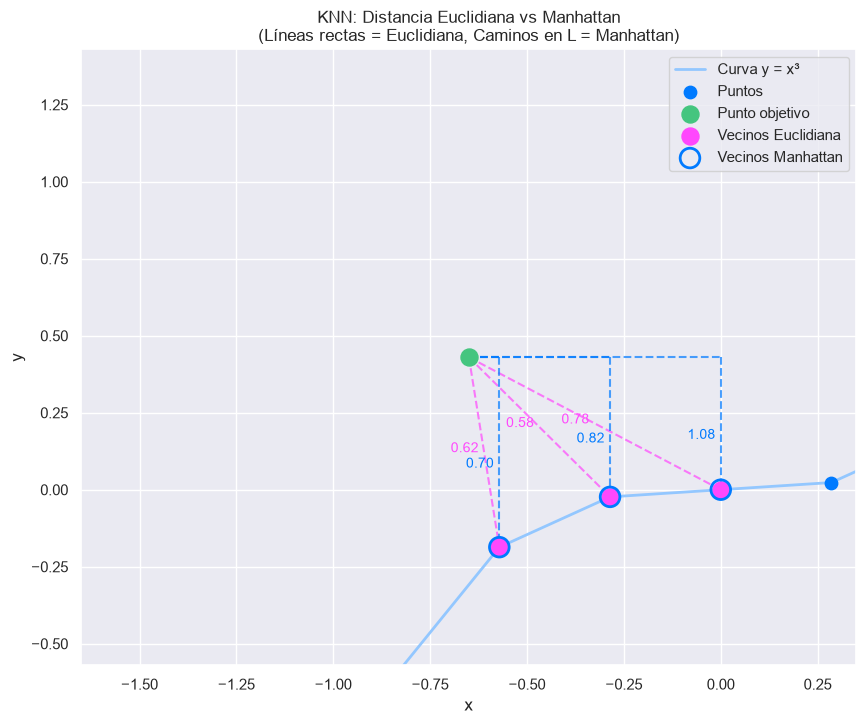

In [4]:
# Datos de ejemplo con y = x^3
x = np.linspace(-2, 2, 15)
y = x**3
data = np.column_stack((x, y))

# Punto objetivo
punto = np.array([-0.65, 0.43])

# Calculo distancias Euclidiana y Manhattan
dist_euclid = np.sqrt(np.sum((data - punto)**2, axis=1))
dist_manhattan = np.sum(np.abs(data - punto), axis=1)

# Vecinos más cercanos (k=3)
k = 3
idx_euclid = np.argsort(dist_euclid)[:k]
idx_manhattan = np.argsort(dist_manhattan)[:k]
vecinos_euclid = data[idx_euclid]
vecinos_manhattan = data[idx_manhattan]

# Gráfico
plt.figure(figsize=(10, 8))
plt.plot(x, y, color='#93c7ff', linewidth=2, label='Curva y = x³')
plt.scatter(x, y, color='#007aff', s=80, label='Puntos', zorder=2)
plt.scatter(*punto, color='#44c57f', s=150, zorder=5, label='Punto objetivo')

# Vecinos Euclidiana
plt.scatter(vecinos_euclid[:, 0], vecinos_euclid[:, 1],
            color='#ff48fd', s=150, zorder=4, label='Vecinos Euclidiana')
for i, vecino in enumerate(vecinos_euclid):
    plt.plot([punto[0], vecino[0]], [punto[1], vecino[1]],
             color='#ff48fd', linestyle='--', alpha=0.7)
    dist = dist_euclid[idx_euclid[i]]
    mid_x = (punto[0] + vecino[0]) / 2
    mid_y = (punto[1] + vecino[1]) / 2
    plt.text(mid_x - 0.05, mid_y, f'{dist:.2f}', color='#ff48fd',
             fontsize=10, ha='center')

# Vecinos Manhattan
plt.scatter(vecinos_manhattan[:, 0], vecinos_manhattan[:, 1],
            facecolors='none', edgecolors='#007aff', s=200, linewidths=2,
            zorder=4, label='Vecinos Manhattan')
for i, vecino in enumerate(vecinos_manhattan):
    plt.plot([punto[0], vecino[0]], [punto[1], punto[1]],
             color='#007aff', linestyle='--', alpha=0.7)
    plt.plot([vecino[0], vecino[0]], [punto[1], vecino[1]],
             color='#007aff', linestyle='--', alpha=0.7)
    dist = dist_manhattan[idx_manhattan[i]]
    mid_x = vecino[0]
    mid_y = (punto[1] + vecino[1]) / 2
    plt.text(mid_x - 0.05, mid_y - 0.05, f'{dist:.2f}', color='#007aff',
             fontsize=10, ha='center')

# Ajusto límites para mostrar más contexto
padding = 1
plt.xlim(punto[0] - padding, punto[0] + padding)
plt.ylim(punto[1] - padding, punto[1] + padding)

plt.xlabel('x')
plt.ylabel('y')
plt.title("KNN: Distancia Euclidiana vs Manhattan\n"
          "(Líneas rectas = Euclidiana, Caminos en L = Manhattan)")
plt.legend()

# Tabla de distancias
print("Distancias a los vecinos más cercanos:")
print("\nEuclidiana:")
for i, idx in enumerate(idx_euclid):
    print(f"Vecino {i+1}: Punto {data[idx]}, Distancia = {dist_euclid[idx]:.2f}")
print("\nManhattan:")
for i, idx in enumerate(idx_manhattan):
    print(f"Vecino {i+1}: Punto {data[idx]}, Distancia = {dist_manhattan[idx]:.2f}")

plt.show()